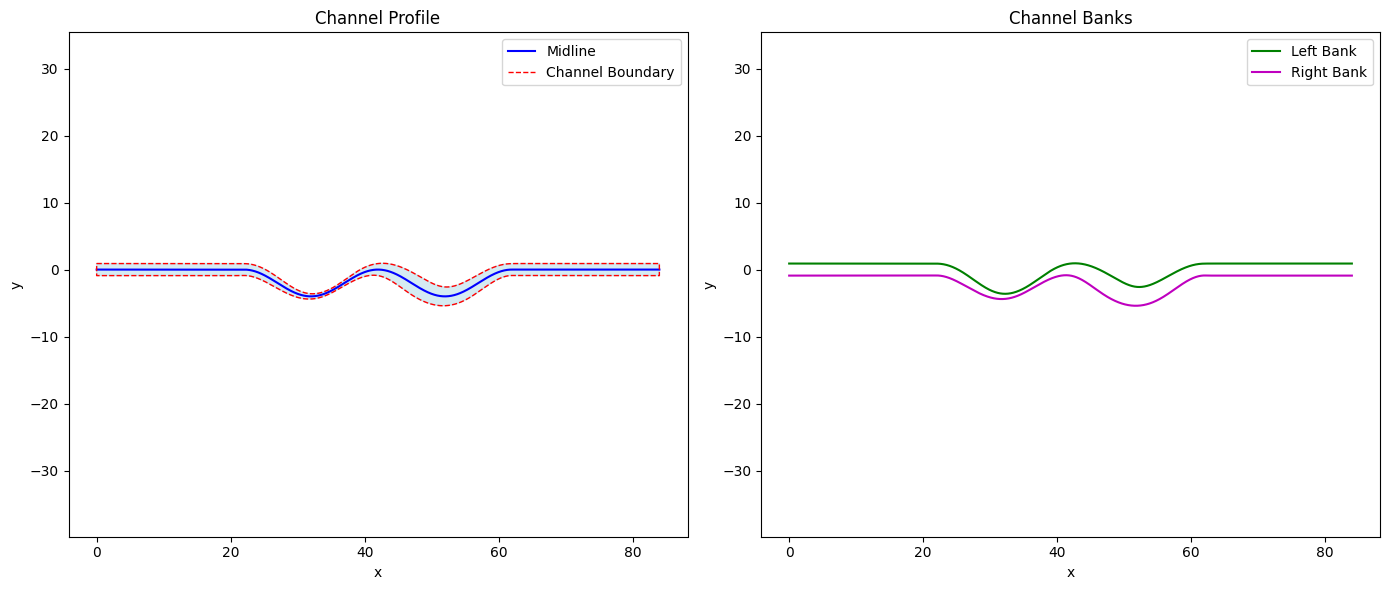

Computing widths. This may take a while...
Width compute finished.


C:\Users\cwtseae\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\src\bo_sheet\channel_preprocess_utility.py:1122: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)
C:\Users\cwtseae\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\src\bo_sheet\channel_preprocess_utility.py:1145: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig2.subplots_adjust(right=0.85)


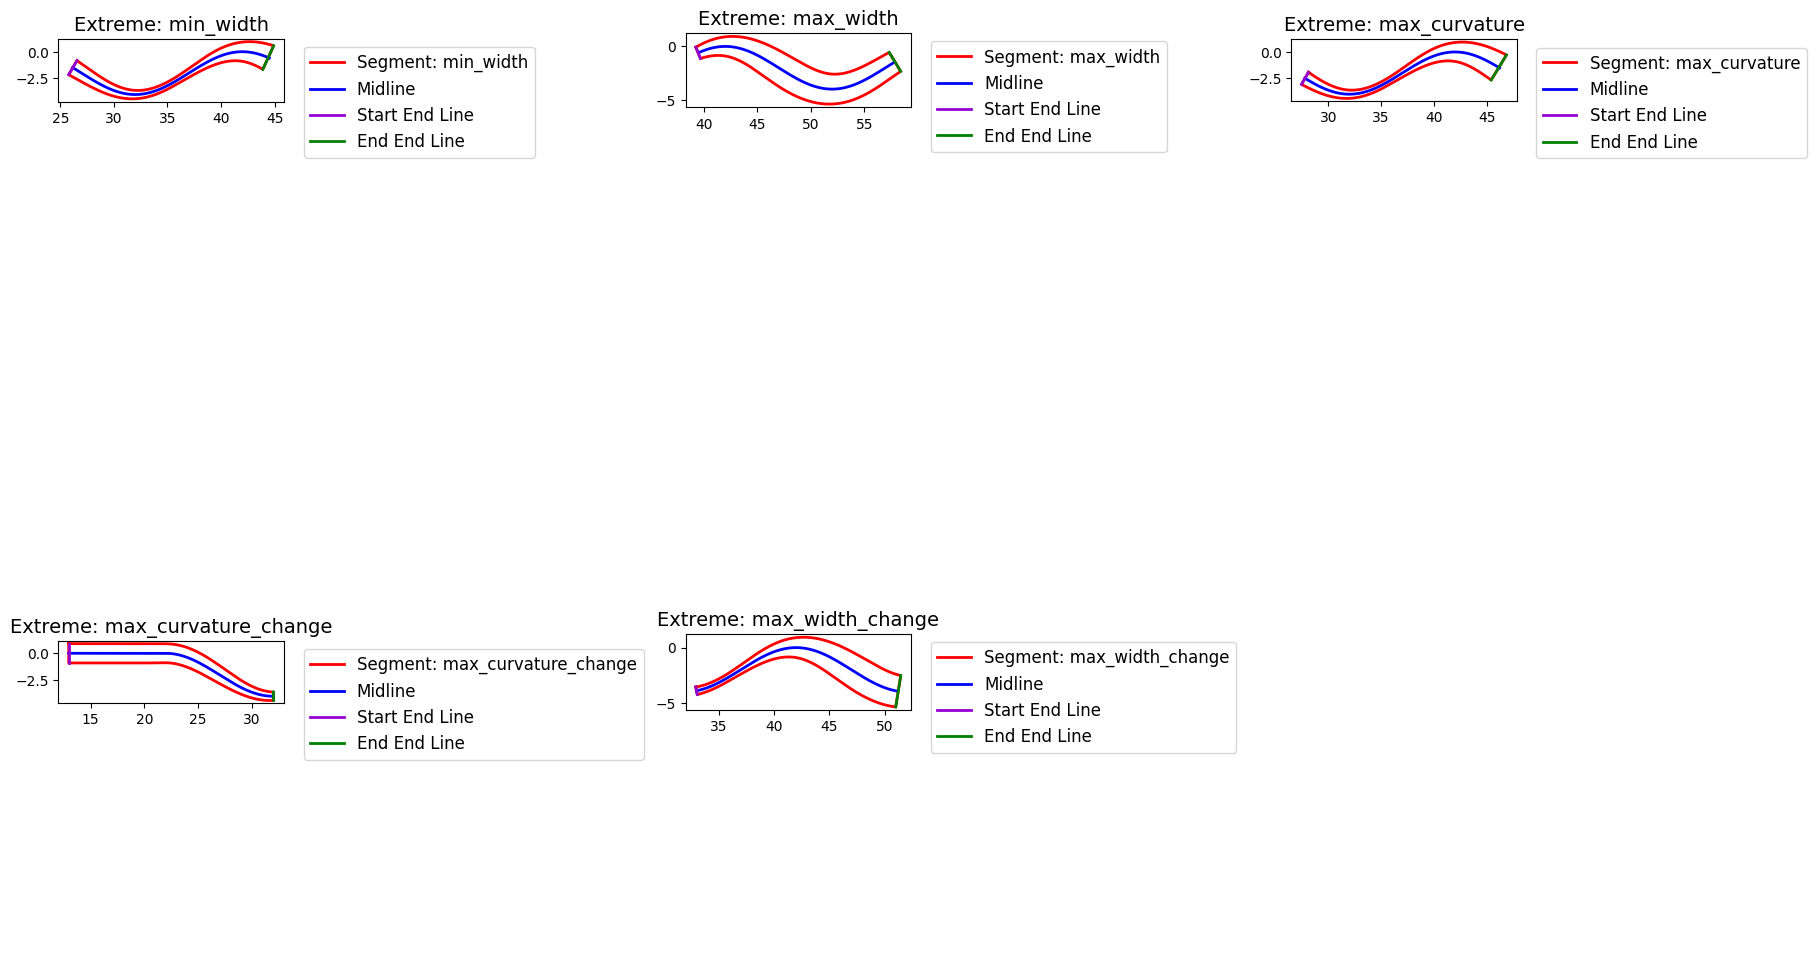

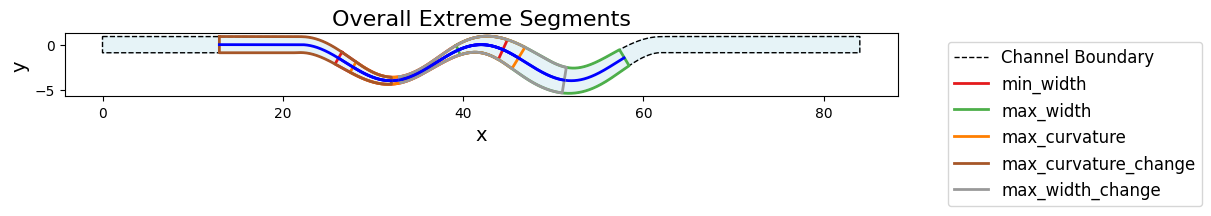

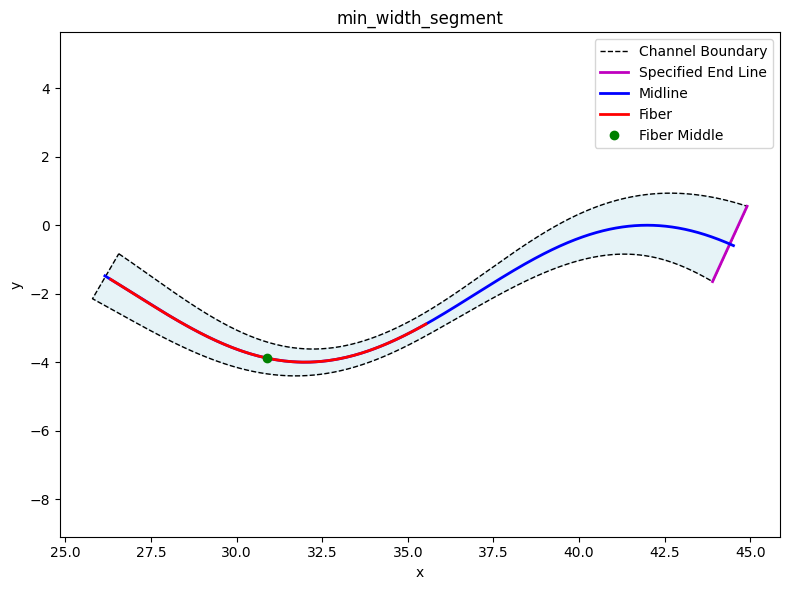

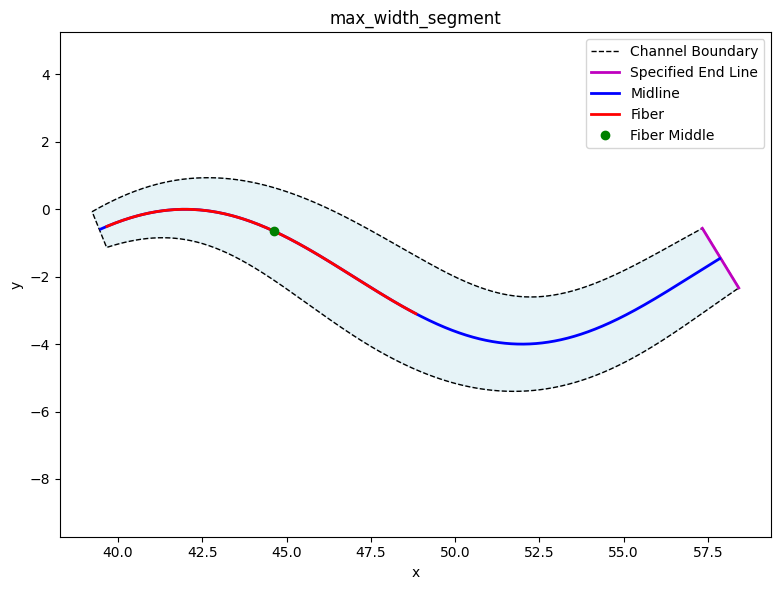

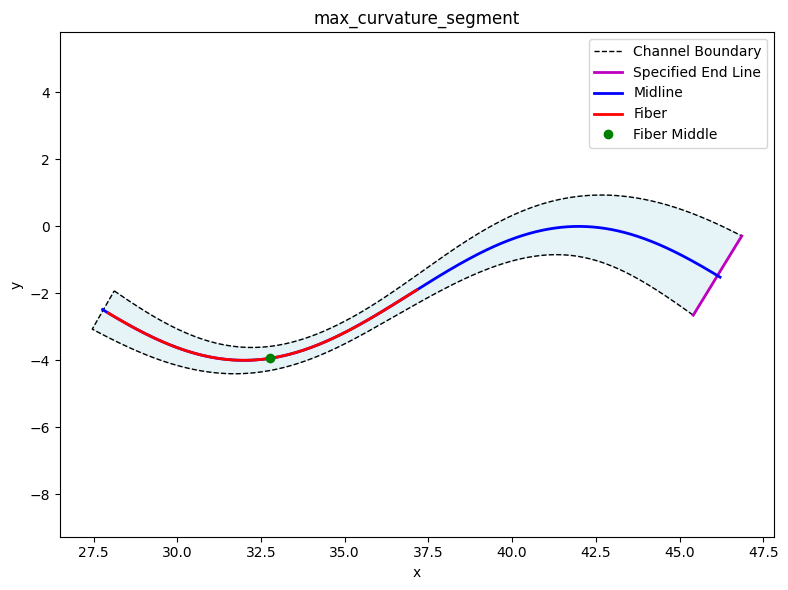

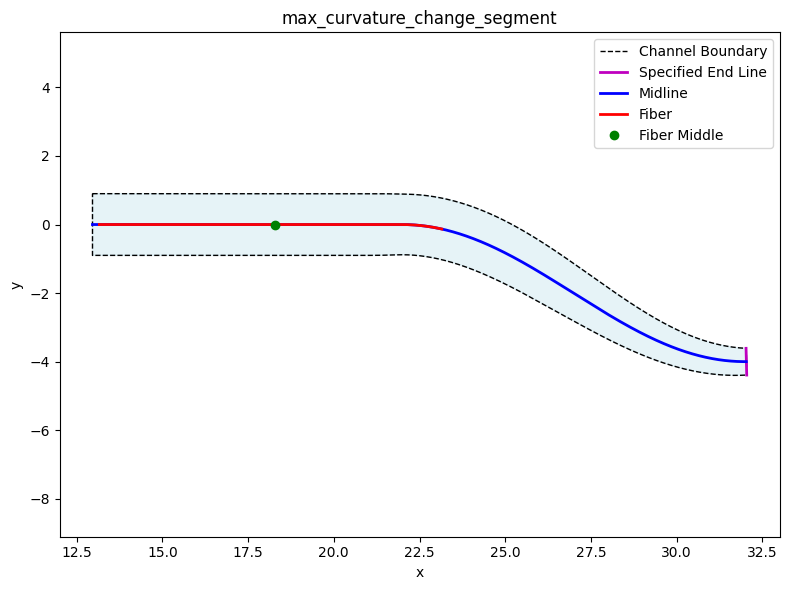

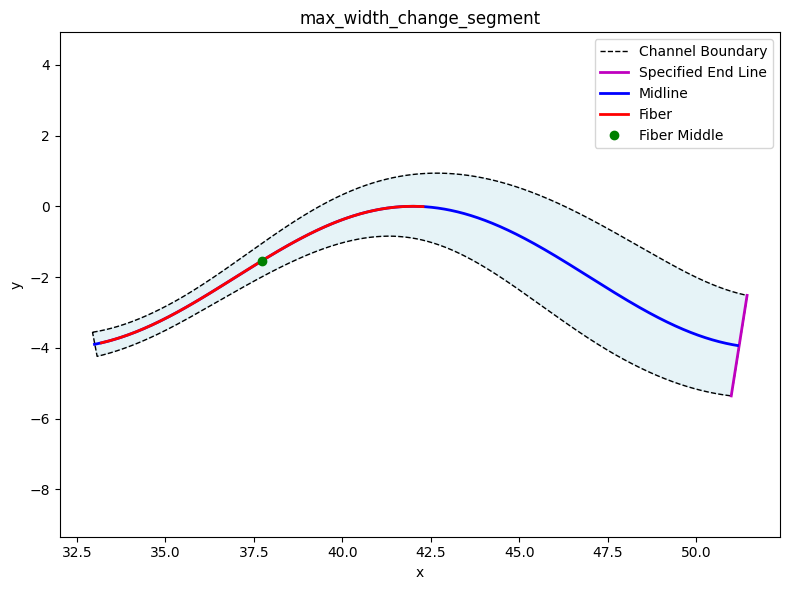

In [ ]:
import os
import bo_sheet.channel_preprocess_utility as cu
import numpy as np
import numpy.typing as npt
from shapely.geometry import Polygon
from shapely.wkt import loads

upper_bound_robot_length = 10.0
end_line_percent = 1.0

# L_window means the length along midline which is used to segment for interesting
# channel geometry
L_window = 2.0 * upper_bound_robot_length
offset_factor = 0.0
precise_offset = 0.2

parent_directory = os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'Bayesian_Optimization_for_Sheet_Robots', \
                              'tasks', '3_optim_shape')

sinusoidal_dir = os.path.join(parent_directory, 'channel_params', 'sinusoidal')

with np.load(os.path.join(sinusoidal_dir, "channel_info.npz")) as channel_info:
    x_midline = channel_info['x_midline']
    y_midline = channel_info['y_midline']
    left_bank = channel_info['left_bank']
    right_bank = channel_info['right_bank']
    total_length = channel_info['total_length']
    channel_info.close()

with open(os.path.join(sinusoidal_dir, 'polygon.wkt'), 'r') as file:
    channel_polygon = loads(file.read())
    file.close()

cu.plot_channel_all_info(x_midline, y_midline, channel_polygon, left_bank, right_bank)

# 100 points in make_segment() may be too few.
# 'min_width', 'max_width', 'max_curvature', 'max_curvature_change', 'max_width_change'
# Each key returns (seg_poly, seg_mid, left_seg, right_seg, s_window)
extreme_segments = cu.segment_channel_extreme(x_midline, y_midline, left_bank, right_bank, L_window, 100)
cu.plot_extreme_segments(extreme_segments, channel_polygon)

# But we need the segmented curve length, x_midline and y_midline information
# And left_bank and right_bank for experiment reconstruction
for key in extreme_segments.keys():
    seg_poly = extreme_segments[key][0]
    seg_mid = extreme_segments[key][1]
    left_seg = extreme_segments[key][2]
    right_seg = extreme_segments[key][3]
    L_window = extreme_segments[key][4]

    with open(os.path.join(sinusoidal_dir, f"{key}_polygon.wkt"), "w") as file:
        file.write(seg_poly.wkt)
        file.close()

    channel_info = {
        "x_midline": seg_mid[:, 0],
        "y_midline": seg_mid[:, 1],
        "left_bank": left_seg,
        "right_bank": right_seg,
        "seg_mid": seg_mid,
        "total_length": L_window
    }

    left_bank_numpy: npt.NDArray[np.float64] = channel_info['left_bank']
    right_bank_numpy: npt.NDArray[np.float64] = channel_info['right_bank']

    z_axis = np.full((left_bank_numpy.shape[0], 1), 0.0)

    txt_left_bank = np.hstack((left_bank_numpy, z_axis))
    txt_right_bank = np.hstack((right_bank_numpy, z_axis))

    np.savez(os.path.join(sinusoidal_dir, f"{key}_channel_info"), **channel_info)
    np.savetxt(os.path.join(sinusoidal_dir, f"{key}_boundary_pos.txt"), txt_left_bank, fmt='%.2f', delimiter=',')
    with open(os.path.join(sinusoidal_dir, f"{key}_boundary_pos.txt"), 'a') as file:
        np.savetxt(file, txt_right_bank, fmt='%.2f', delimiter=',')
        file.close()

    fiber = cu.generate_fiber_in_segment(seg_mid, upper_bound_robot_length, offset_factor, 40, precise_offset)

    cu.plot_channel_and_fiber(seg_poly, seg_mid, fiber, f"{key}_segment", end_line_percent)